# QSS 45 Final Project — Notebook 3: Exploratory Data Analysis

**Pooled cross-section EDA.** Operates on the combined April-2024 + May-2026 LinkedIn corpus (~13,870 postings across 5 industries) — see Notebook 2 for the pooling rationale. Temporal-comparison plots (2024 vs 2026 breakdowns) are saved for the **final paper**; this notebook covers the initial-assignment cross-sectional analyses:

1. Overall summary statistics
2. Histograms of continuous variables
3. Bar charts by industry / seniority / employment-type
4. Industry × AI-term heatmap (which industries cluster on which AI terms)
5. AI-term frequency distribution by industry (violin)
6. Source-platform comparison (`linkedin` = 2026, `linkedin_2024` = April 2024) — useful preview of the temporal shift
7. Observations

**Input:** `data/processed/postings_clean.csv`
**Output:** `data/figures/*.png`

In [1]:
# --- Project-root path bootstrap (added by repo-reorg) ---
# Ensures cwd is the project root regardless of where this notebook was
# launched from (root, code/, JupyterLab tree, VS Code, etc.).
import os
from pathlib import Path
_here = Path.cwd().resolve()
while not (_here / 'data').exists() and _here.parent != _here:
    _here = _here.parent
os.chdir(_here)
PROJECT_ROOT = _here
# ---------------------------------------------------------

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')

# ── Style ───────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi':      120,
    'savefig.dpi':     150,
    'savefig.bbox':    'tight',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
})

PROC_DIR = Path('data/processed')
FIG_DIR  = Path('output/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Load data ────────────────────────────────────────────────────────
df = pd.read_csv(PROC_DIR / 'postings_clean.csv', low_memory=False, parse_dates=['date_posted'])

INDUSTRY_LABELS = {
    'pharma_chem':      'Pharma / Chem',
    'legal_services':   'Legal Services',
    'farming_forestry': 'Farming / Forestry',
    'insurance':        'Insurance',
    'patent_ip':        'Patent / IP',
}
df['industry_short'] = df['industry_key'].map(INDUSTRY_LABELS).fillna(df['industry_key'])

FLAG_COLS = [
    'flag_machine_learning', 'flag_artificial_intel', 'flag_automation',
    'flag_llm', 'flag_generative_ai', 'flag_python', 'flag_prompt_eng',
    'flag_nlp', 'flag_deep_learning', 'flag_data_science',
    'flag_gpt', 'flag_copilot', 'flag_predictive', 'flag_cloud_ml',
]
FLAG_LABELS = {
    'flag_machine_learning': 'Machine Learning',
    'flag_artificial_intel': 'Artificial Intelligence / AI',
    'flag_automation':       'Automation',
    'flag_llm':              'LLM',
    'flag_generative_ai':    'Generative AI',
    'flag_python':           'Python',
    'flag_prompt_eng':       'Prompt Engineering',
    'flag_nlp':              'NLP',
    'flag_deep_learning':    'Deep Learning / Neural Nets',
    'flag_data_science':     'Data Science',
    'flag_gpt':              'GPT / ChatGPT / OpenAI',
    'flag_copilot':          'GitHub Copilot',
    'flag_predictive':       'Predictive Analytics',
    'flag_cloud_ml':         'Cloud ML (AWS/Azure/GCP)',
}

PALETTE = sns.color_palette('muted', n_colors=len(INDUSTRY_LABELS))
IND_COLORS = dict(zip(INDUSTRY_LABELS.values(), PALETTE))

print(f'Loaded {len(df):,} postings.')
print(df[['industry_key', 'source_platform', 'date_posted']].head(3))

Loaded 12,487 postings.
  industry_key source_platform date_posted
0  pharma_chem        linkedin         NaT
1  pharma_chem        linkedin  2026-05-12
2  pharma_chem        linkedin  2026-05-12


## 1. Summary Statistics

In [2]:
print('=== Overall Summary ===')
print(df[['word_count', 'ai_term_count', 'ai_term_freq', 'seniority_ordinal', 'ai_exposure_binary']].describe().round(3).to_string())

print('\n=== Postings per Industry ===')
print(df.groupby('industry_short').size().sort_values(ascending=False).to_string())

print('\n=== Source Platform Breakdown (linkedin = 2026, linkedin_2024 = 2024) ===')
print(df['source_platform'].value_counts().to_string())

print('\n=== AI Exposure by Industry ===')
print(df.groupby('industry_short')['ai_exposure_binary'].agg(['mean', 'sum']).rename(
    columns={'mean': 'share_high_ai', 'sum': 'n_high_ai'}).round(3).to_string())

=== Overall Summary ===
       word_count  ai_term_count  ai_term_freq  seniority_ordinal  ai_exposure_binary
count   12487.000      12487.000     12487.000          12487.000           12487.000
mean      618.243          0.232         0.000              2.350               0.163
std       301.522          0.639         0.002              0.842               0.369
min        50.000          0.000         0.000              0.000               0.000
25%       388.000          0.000         0.000              2.000               0.000
50%       606.000          0.000         0.000              2.000               0.000
75%       831.000          0.000         0.000              3.000               0.000
max      2139.000          9.000         0.070              5.000               1.000

=== Postings per Industry ===
industry_short
Pharma / Chem         4581
Insurance             3360
Legal Services        2215
Patent / IP           1231
Farming / Forestry    1100

=== Source Platform 

## 2. Histograms — Continuous Variables

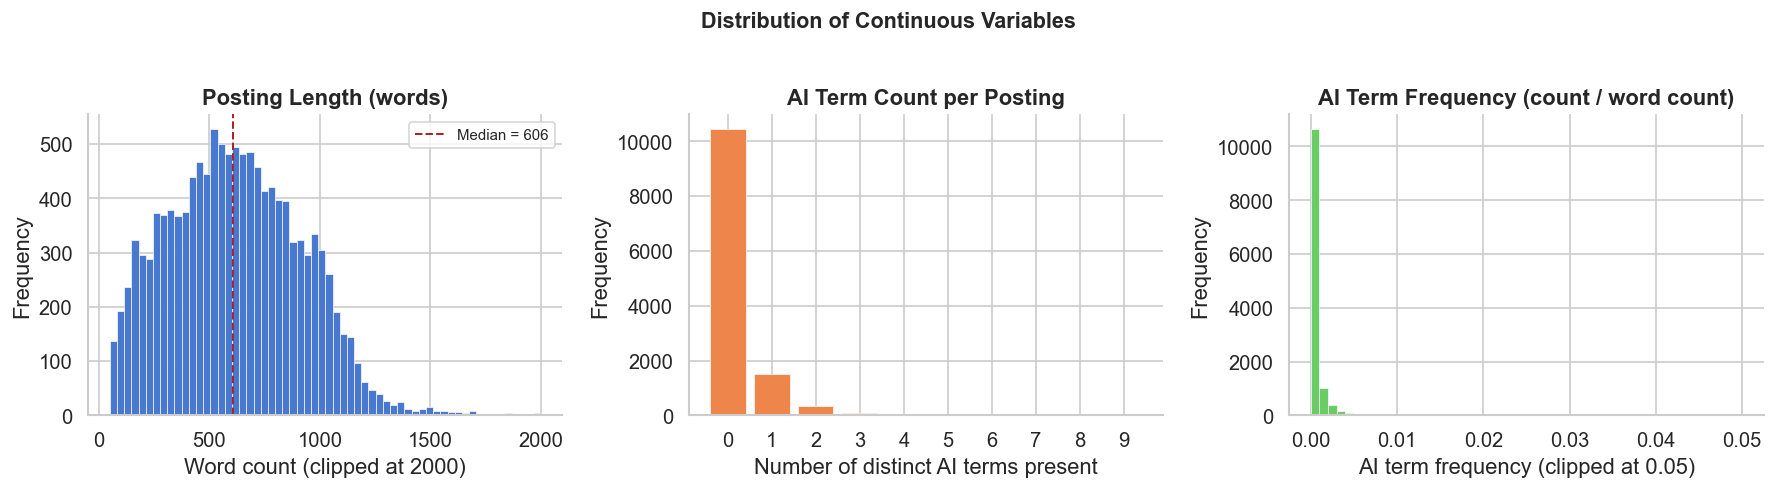

Figure 1 saved.


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Posting length ---
ax = axes[0]
ax.hist(df['word_count'].clip(upper=2000), bins=60, color=sns.color_palette('muted')[0],
        edgecolor='white', linewidth=0.4)
ax.axvline(df['word_count'].median(), color='firebrick', linestyle='--', linewidth=1.2,
           label=f'Median = {df["word_count"].median():.0f}')
ax.set_title('Posting Length (words)', fontweight='bold')
ax.set_xlabel('Word count (clipped at 2000)')
ax.set_ylabel('Frequency')
ax.legend(fontsize=9)

# --- AI term count ---
ax = axes[1]
counts = df['ai_term_count'].value_counts().sort_index()
ax.bar(counts.index, counts.values, color=sns.color_palette('muted')[1], edgecolor='white', linewidth=0.4)
ax.set_title('AI Term Count per Posting', fontweight='bold')
ax.set_xlabel('Number of distinct AI terms present')
ax.set_ylabel('Frequency')
ax.set_xticks(range(int(df['ai_term_count'].max()) + 1))

# --- AI term frequency (normalised) ---
ax = axes[2]
ax.hist(df['ai_term_freq'].clip(upper=0.05), bins=50,
        color=sns.color_palette('muted')[2], edgecolor='white', linewidth=0.4)
ax.set_title('AI Term Frequency (count / word count)', fontweight='bold')
ax.set_xlabel('AI term frequency (clipped at 0.05)')
ax.set_ylabel('Frequency')

fig.suptitle('Distribution of Continuous Variables', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_histograms_continuous.png')
plt.show()
print('Figure 1 saved.')

## 3. Bar Charts — Categorical Variables

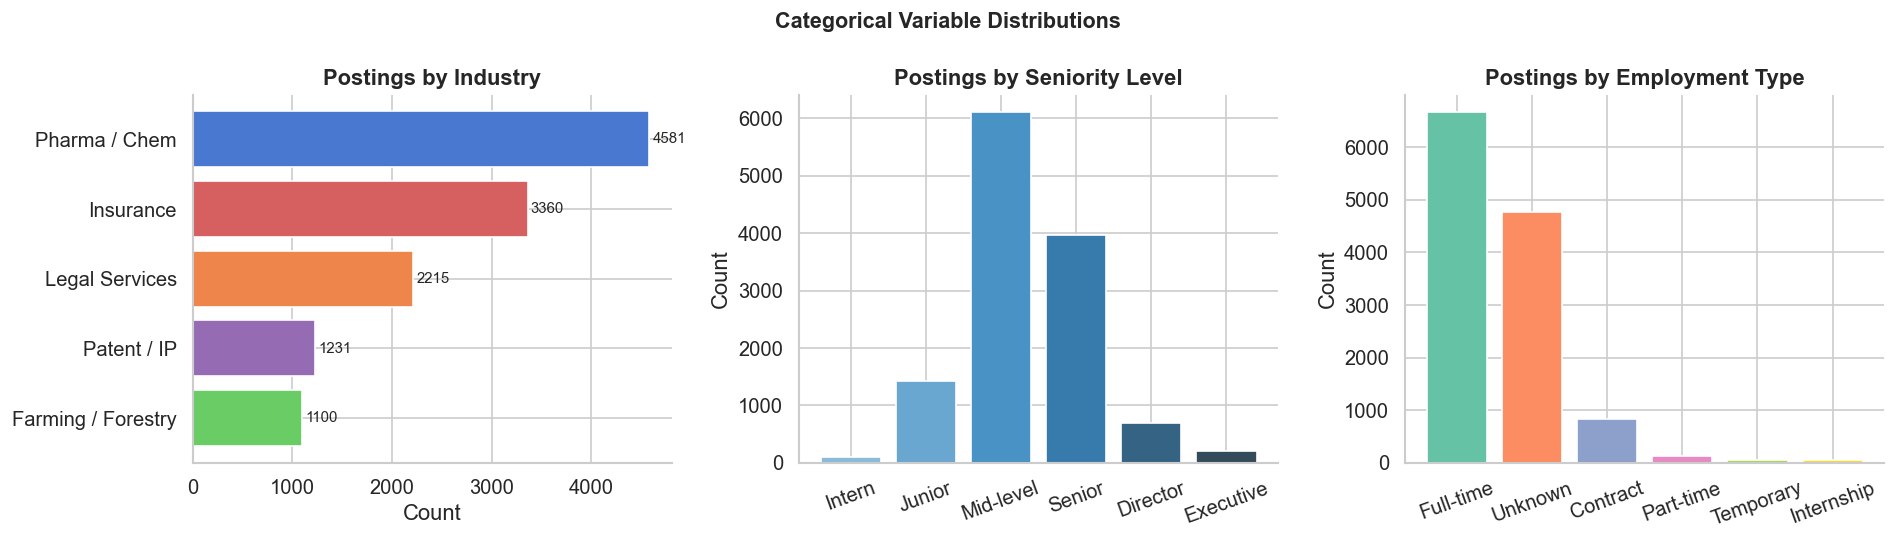

Figure 2 saved.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

# --- Industry ---
ax = axes[0]
ind_counts = df['industry_short'].value_counts().sort_values(ascending=True)
colors = [IND_COLORS.get(i, '#888') for i in ind_counts.index]
ax.barh(ind_counts.index, ind_counts.values, color=colors, edgecolor='white')
ax.set_title('Postings by Industry', fontweight='bold')
ax.set_xlabel('Count')
for i, v in enumerate(ind_counts.values):
    ax.text(v + 30, i, str(v), va='center', fontsize=9)

# --- Seniority ---
ax = axes[1]
seniority_labels = {0: 'Intern', 1: 'Junior', 2: 'Mid-level', 3: 'Senior', 4: 'Director', 5: 'Executive'}
sen_counts = df['seniority_ordinal'].map(seniority_labels).value_counts().reindex(
    list(seniority_labels.values()), fill_value=0)
ax.bar(sen_counts.index, sen_counts.values,
       color=sns.color_palette('Blues_d', n_colors=6), edgecolor='white')
ax.set_title('Postings by Seniority Level', fontweight='bold')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=20)

# --- Employment type ---
ax = axes[2]
emp_counts = df['employment_type_clean'].value_counts().head(6)
ax.bar(emp_counts.index, emp_counts.values,
       color=sns.color_palette('Set2', n_colors=len(emp_counts)), edgecolor='white')
ax.set_title('Postings by Employment Type', fontweight='bold')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=20)

fig.suptitle('Categorical Variable Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_bar_charts_categorical.png')
plt.show()
print('Figure 2 saved.')

## 4. AI-Term Prevalence — Industry × Term Heatmap

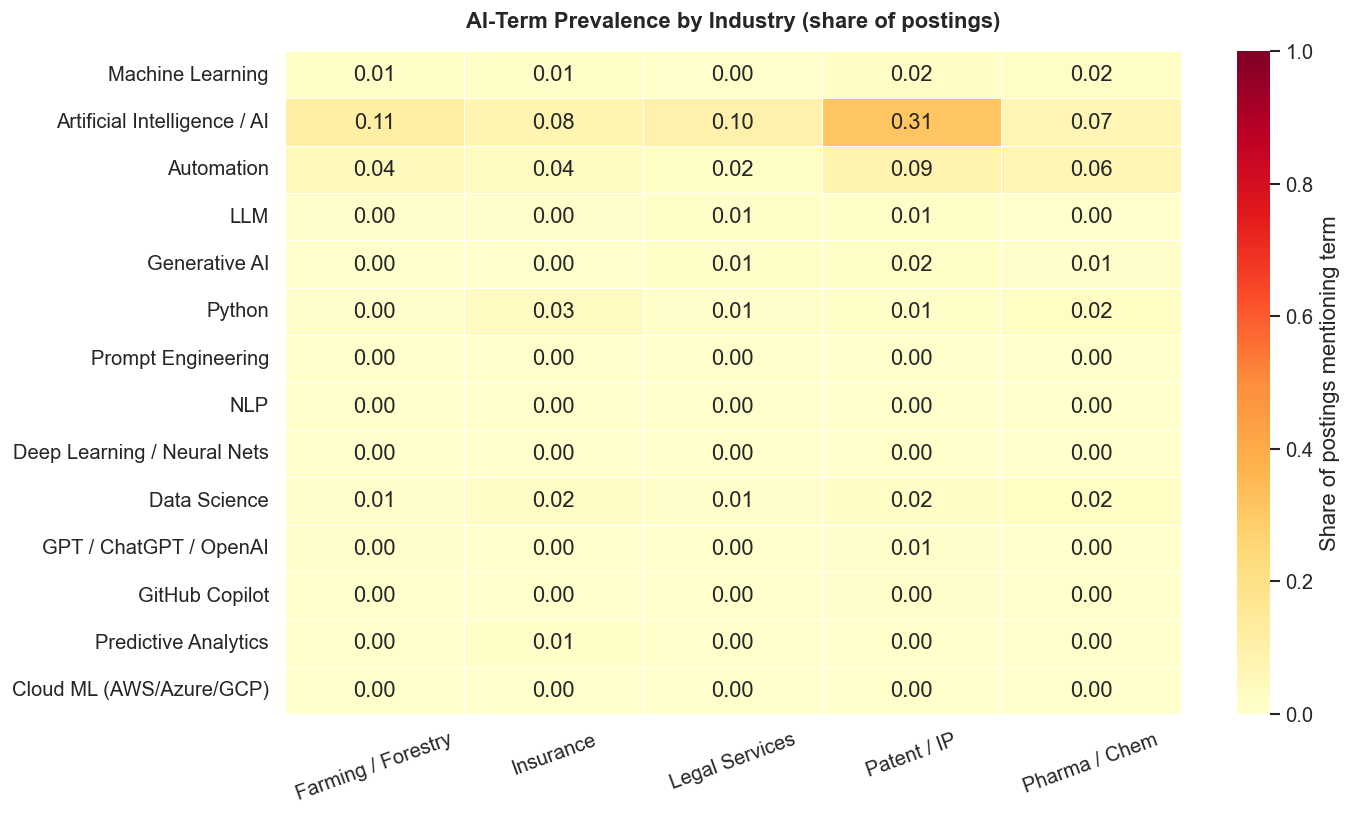

Figure 4 saved.


In [5]:
flag_cols_present = [c for c in FLAG_COLS if c in df.columns]

# Mean flag rate per industry
heat = df.groupby('industry_short')[flag_cols_present].mean().T
heat.index = [FLAG_LABELS.get(c, c) for c in heat.index]

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    heat,
    ax=ax,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.4,
    linecolor='white',
    vmin=0,
    vmax=1,
    cbar_kws={'label': 'Share of postings mentioning term'},
)
ax.set_title('AI-Term Prevalence by Industry (share of postings)', fontweight='bold', pad=14)
ax.set_ylabel('')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_ai_term_heatmap_industry.png')
plt.show()
print('Figure 4 saved.')

## 5. AI-Term Frequency Distribution by Industry

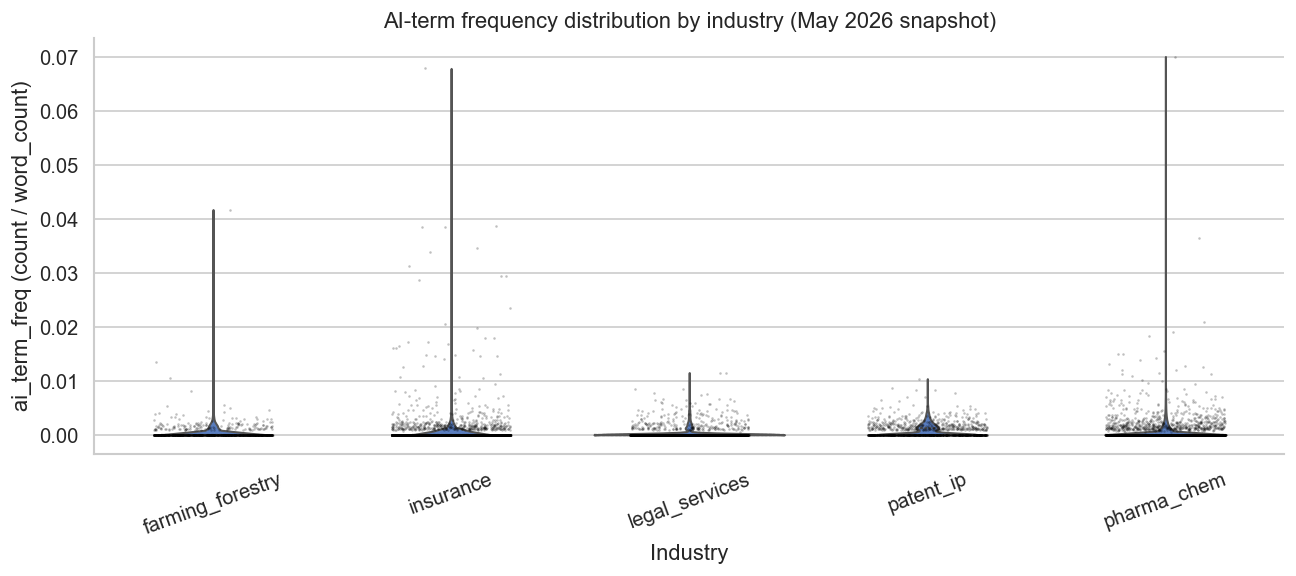

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
order = df.groupby('industry_key')['ai_term_freq'].median().sort_values(ascending=False).index.tolist()
sns.violinplot(data=df, x='industry_key', y='ai_term_freq', order=order, inner='quartile', cut=0, ax=ax)
sns.stripplot(data=df, x='industry_key', y='ai_term_freq', order=order,
              size=1.5, color='black', alpha=0.25, jitter=0.25, ax=ax)
ax.set_title('AI-term frequency distribution by industry (May 2026 snapshot)')
ax.set_xlabel('Industry')
ax.set_ylabel('ai_term_freq (count / word_count)')
ax.tick_params(axis='x', rotation=20)
fig.tight_layout()
fig.savefig(FIG_DIR / 'industry_ai_violin.png', dpi=150)
plt.show()

## 6. Source Platform Comparison

,source_platform,n,mean_ai_freq,mean_word_count,pct_high_ai
0,linkedin,4766,0.0005,736.7125,0.2709
1,linkedin_2024,7721,0.0004,545.1145,0.0962


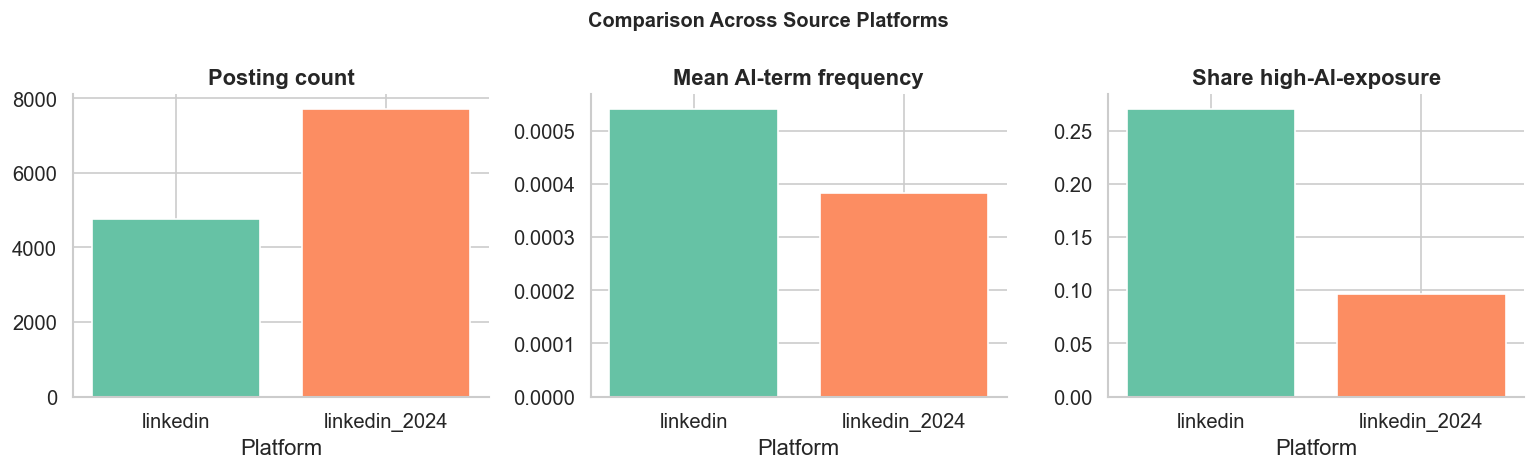

Figure 8 saved.


In [7]:
platform_summary = df.groupby('source_platform').agg(
    n=('job_id', 'count'),
    mean_ai_freq=('ai_term_freq', 'mean'),
    mean_word_count=('word_count', 'mean'),
    pct_high_ai=('ai_exposure_binary', 'mean'),
).reset_index()

display(platform_summary.round(4))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (col, title) in zip(axes, [
    ('n', 'Posting count'),
    ('mean_ai_freq', 'Mean AI-term frequency'),
    ('pct_high_ai', 'Share high-AI-exposure'),
]):
    ax.bar(platform_summary['source_platform'], platform_summary[col],
           color=sns.color_palette('Set2', n_colors=len(platform_summary)), edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Platform')

fig.suptitle('Comparison Across Source Platforms', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig8_platform_comparison.png')
plt.show()
print('Figure 8 saved.')

## 7. EDA Observations

**Distribution shape**
- Posting length is right-skewed with a long tail; the median is **606 words** (IQR ≈ 390–830, floor at 50 from cleaning).
- AI-term count is sharply zero-inflated — more than three-quarters of postings mention **zero** AI terms (mean 0.23), so the normalized `ai_term_freq` piles up near zero with a thin positive tail.
- AI language is a minority phenomenon overall: only **16.3%** of postings mention at least one AI term.

**2024 vs 2026 (two snapshots, not a time series)**
- The keyword AI-exposure share nearly triples between snapshots: **9.6%** in the 2024 archive (`linkedin_2024`) vs **27.1%** in the 2026 scrape (`linkedin`).
- 2026 descriptions run ~35% longer on average (737 vs 545 words), which inflates raw keyword *counts* — the length-normalized `ai_term_freq` is the more comparable measure.
- `year` is confounded with the data source (2024 = external Kaggle archive, 2026 = own scrape), so this is a two-snapshot comparison rather than a temporal trend.

**Industry heterogeneity**
- By raw pooled share, **Patent/IP** is the clear standout (~36% of postings mention an AI term); the other four industries are lower and similar (~12–15%).
- These raw pooled rates are confounded by the differing 2024/2026 mix across industries (a field that is mostly 2026 postings looks more AI-exposed), so the **source-adjusted odds ratios in Notebook 4** are the cleaner industry signal — there Patent/IP and Pharma lead.